### Dataset: MSU-MFSD
### Task: live vs spoof (print/replay)
### Models: MobileNetV2 baseline + MobileNetV2 with frequency cue
### Metrics: APCER/BPCER/ACER + EER (dev)

In [ ]:
MSU_ROOT = "/datasets/msu_mfsd_raw" 
WORK_ROOT = "data/work"

In [16]:
!python3 src/prepare_msu.py --msu_root "{MSU_ROOT}" --out_root "{WORK_ROOT}" --frames_per_video 8 --dev_frac 0.33 --seed 42

Extracting frames:  51%|███████████▎          | 144/280 [00:32<00:24,  5.62it/s][prores @ 0x11bc10140] error, wrong slice data size
[prores @ 0x11bc10140] error decoding picture header
Extracting frames:  66%|██████████████▍       | 184/280 [00:41<00:25,  3.84it/s][prores @ 0x11bb10790] ac tex damaged 1024, 1024
[prores @ 0x11bb10790] invalid plane data size
[prores @ 0x11bb10790] invalid plane data size
Extracting frames:  68%|██████████████▉       | 190/280 [00:43<00:23,  3.84it/s][prores @ 0x14c6b5ad0] error, slice out of bounds
[prores @ 0x14c6b5ad0] error decoding picture header
Extracting frames:  69%|███████████████▏      | 193/280 [00:44<00:21,  4.08it/s][prores @ 0x11bc0e050] ac tex damaged 1029, 1024
[prores @ 0x11bc0e050] invalid plane data size
[prores @ 0x11bc0e050] invalid plane data size
[prores @ 0x11bc0e050] invalid plane data size
[prores @ 0x11bc0e050] invalid plane data size
[prores @ 0x11bc0e050] invalid plane data size
[prores @ 0x11bc0e050] invalid plane data siz

In [17]:
import pandas as pd
for s in ["train","dev","test"]:
    dfv = pd.read_csv(f"{WORK_ROOT}/splits/{s}_videos.csv")
    dff = pd.read_csv(f"{WORK_ROOT}/splits/{s}_frames.csv")
    print(s, "videos:", len(dfv), "frames:", len(dff))


train videos: 88 frames: 699
dev videos: 32 frames: 256
test videos: 160 frames: 1278


In [ ]:
!python3 src/train_msu.py --work_root "{WORK_ROOT}" --epochs 8 --lr 1e-4


Using pos_weight: 2.971590995788574 | train neg: 523 pos: 176
epoch 1: 100%|██████████████████████████████████| 22/22 [02:15<00:00,  6.15s/it]
{'epoch': 1, 'loss': 1.0050490390170703, 'dev_acc': 0.25, 'dev_bal_acc': 0.5, 'dev_confusion': {'tp': 64, 'tn': 0, 'fp': 192, 'fn': 0}}
epoch 2: 100%|██████████████████████████████████| 22/22 [02:14<00:00,  6.10s/it]
{'epoch': 2, 'loss': 0.7968774573369459, 'dev_acc': 0.25, 'dev_bal_acc': 0.5, 'dev_confusion': {'tp': 64, 'tn': 0, 'fp': 192, 'fn': 0}}
epoch 3: 100%|██████████████████████████████████| 22/22 [02:14<00:00,  6.09s/it]
{'epoch': 3, 'loss': 0.33245799284089694, 'dev_acc': 0.75, 'dev_bal_acc': 0.5, 'dev_confusion': {'tp': 0, 'tn': 192, 'fp': 0, 'fn': 64}}
epoch 4: 100%|██████████████████████████████████| 22/22 [02:13<00:00,  6.08s/it]
{'epoch': 4, 'loss': 0.10634594393724744, 'dev_acc': 0.93359375, 'dev_bal_acc': 0.8671875, 'dev_confusion': {'tp': 47, 'tn': 192, 'fp': 0, 'fn': 17}}
epoch 5: 100%|██████████████████████████████████| 22/22

In [ ]:
!python3 src/train_msu.py --work_root "{WORK_ROOT}" --epochs 8 --lr 1e-4 --use_freq


Using pos_weight: 2.971590995788574 | train neg: 523 pos: 176
epoch 1: 100%|██████████████████████████████████| 22/22 [02:15<00:00,  6.17s/it]
{'epoch': 1, 'loss': 0.9847635708071969, 'dev_acc': 0.75, 'dev_bal_acc': 0.5, 'dev_confusion': {'tp': 0, 'tn': 192, 'fp': 0, 'fn': 64}}
epoch 2: 100%|██████████████████████████████████| 22/22 [02:14<00:00,  6.13s/it]
{'epoch': 2, 'loss': 0.571948529644446, 'dev_acc': 0.75, 'dev_bal_acc': 0.5, 'dev_confusion': {'tp': 0, 'tn': 192, 'fp': 0, 'fn': 64}}
epoch 3: 100%|██████████████████████████████████| 22/22 [02:17<00:00,  6.27s/it]
{'epoch': 3, 'loss': 0.1887804354456338, 'dev_acc': 0.75, 'dev_bal_acc': 0.5, 'dev_confusion': {'tp': 0, 'tn': 192, 'fp': 0, 'fn': 64}}
epoch 4: 100%|██████████████████████████████████| 22/22 [02:15<00:00,  6.15s/it]
{'epoch': 4, 'loss': 0.07698959781026299, 'dev_acc': 0.78125, 'dev_bal_acc': 0.5625, 'dev_confusion': {'tp': 8, 'tn': 192, 'fp': 0, 'fn': 56}}
epoch 5: 100%|██████████████████████████████████| 22/22 [02:16<0

In [ ]:
!python3 src/eval_msu.py --work_root "{WORK_ROOT}" --ckpt runs/msu_rgb_best.pt --max_apcer 0.01

Scoring frames: 100%|███████████████████████████| 20/20 [00:49<00:00,  2.48s/it]
=== VIDEO LEVEL RESULTS ===
{'use_freq': False, 'dev_thr_eer': 0.5809138603508472, 'dev_eer': 0.0}
{'test_apcer': 0.008333333333333333, 'test_bpcer': 0.05, 'test_acer': 0.029166666666666667, 'test_acc': 0.98125}
{'dev_thr_min_acer': 0.5809138603508472, 'dev_acer': 0.0, 'dev_apcer': 0.0, 'dev_bpcer': 0.0, 'dev_acc': 1.0}
{'test_apcer_at_min_acer': 0.008333333333333333, 'test_bpcer_at_min_acer': 0.05, 'test_acer_at_min_acer': 0.029166666666666667, 'test_acc_at_min_acer': 0.98125}
{'dev_apcer_constraint': 0.01, 'dev_thr': 0.5809138603508472, 'dev_apcer': 0.0, 'dev_bpcer': 0.0}
{'test_apcer_at_constraint': 0.008333333333333333, 'test_bpcer_at_constraint': 0.05, 'test_acer_at_constraint': 0.029166666666666667, 'test_acc_at_constraint': 0.98125}


In [ ]:
!python3 src/eval_msu.py --work_root "{WORK_ROOT}" --ckpt runs/msu_rgbfreq_best.pt --max_apcer 0.01


Scoring frames: 100%|███████████████████████████| 20/20 [00:52<00:00,  2.64s/it]
=== VIDEO LEVEL RESULTS ===
{'use_freq': True, 'dev_thr_eer': 0.7986656799912453, 'dev_eer': 0.0}
{'test_apcer': 0.0, 'test_bpcer': 0.1, 'test_acer': 0.05, 'test_acc': 0.975}
{'dev_thr_min_acer': 0.7986656799912453, 'dev_acer': 0.0, 'dev_apcer': 0.0, 'dev_bpcer': 0.0, 'dev_acc': 1.0}
{'test_apcer_at_min_acer': 0.0, 'test_bpcer_at_min_acer': 0.1, 'test_acer_at_min_acer': 0.05, 'test_acc_at_min_acer': 0.975}
{'dev_apcer_constraint': 0.01, 'dev_thr': 0.7986656799912453, 'dev_apcer': 0.0, 'dev_bpcer': 0.0}
{'test_apcer_at_constraint': 0.0, 'test_bpcer_at_constraint': 0.1, 'test_acer_at_constraint': 0.05, 'test_acc_at_constraint': 0.975}


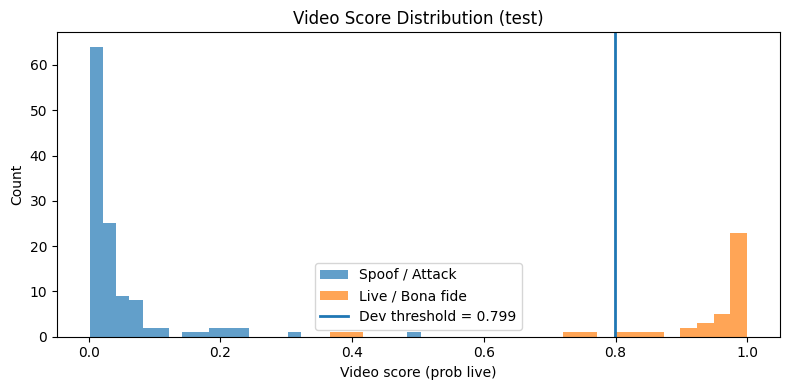

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DEV_THR = 0.7986656799912453  
SPLIT = "test"                # we can see "dev" or "test"

csv_path = f"runs/{SPLIT}_video_scores.csv"
df = pd.read_csv(csv_path)

scores = df["prob_live"].to_numpy(dtype=float)
labels = df["label"].to_numpy(dtype=int)

live_scores = scores[labels == 1]
spoof_scores = scores[labels == 0]

Path("figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,4))
plt.hist(spoof_scores, bins=25, alpha=0.7, label="Spoof / Attack")
plt.hist(live_scores,  bins=25, alpha=0.7, label="Live / Bona fide")
plt.axvline(float(DEV_THR), linewidth=2, label=f"Dev threshold = {float(DEV_THR):.3f}")
plt.title(f"Video Score Distribution ({SPLIT})")
plt.xlabel("Video score (prob live)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("figures/score_hist.png", dpi=200)
plt.show()
